# 06 — LSTM Classification
LSTM (Long Short-Term Memory) captures **temporal dependencies** in the sequence of returns.
We use a sliding window of 10 days as input, sigmoid activation for binary output.


In [1]:
from google.colab import files
files.upload()

Saving gold_silver_final.csv to gold_silver_final.csv


{'gold_silver_final.csv': b'Date,gold,silver,vix,interest,usd_idx,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean,garch_vol_au,garch_vol_ag,vol_regime_au,vol_regime_ag,period_regime,au_lag1,ag_lag1,au_lag2,ag_lag2,au_lag5,ag_lag5,vix_chg,usd_chg,interest_chg,au_ag_ratio,au_ag_ratio_z,garch_vol_au_lag1,garch_vol_ag_lag1,target_au,target_ag\n2010-02-10,80.02999878,1075.800049,15.30200005,3.694000006,25.39999962,0.00212644,-0.000836146,0.004226105,0.014777727,0.001701255,-0.000796224,0.0048314500454298,0.0161917220668841,high_vol,high_vol,pre_covid,-0.00549455,0.010268948,-0.001741936,0.012748651,0.004546044,-0.005384076,-0.008359776554101916,-0.023076937692307675,0.06100010900000008,0.07439114624914839,0.9684986710231442,0.0048013328624082,0.0165892287460453,0,1\n2010-02-11,79.98999786,1094.199951,15.59200001,3.73300004,23.95999908,-0.000499949,0.016958842,0.004221825,0.014931007,0.001372035,0.000973465,0.0047542641024949,0.0156375957870671,high_vol,high_vol,pre_covid,0.00212644,-0.0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('gold_silver_final.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Loaded: {df.shape}")

Loaded: (4051, 31)


In [3]:
FEATURES = [
    'au_returns', 'ag_returns',
    'au_vol', 'ag_vol', 'au_mean', 'ag_mean',
    'au_lag1', 'au_lag2', 'au_lag5',
    'ag_lag1', 'ag_lag2', 'ag_lag5',
    'vix', 'interest', 'usd_idx',
    'vix_chg', 'usd_chg', 'interest_chg',
    'garch_vol_au', 'garch_vol_ag',
    'garch_vol_au_lag1', 'garch_vol_ag_lag1',
    'au_ag_ratio_z'
]

In [4]:
def evaluate_clf(y_true, y_pred, name, asset):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted')
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n  {name} — {asset}")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    F1        : {f1:.4f}")
    print(f"    Precision : {prec:.4f}")
    print(f"    Recall    : {rec:.4f}")
    return {"model": name, "asset": asset, "accuracy": acc, "f1": f1}

def regime_eval(results_df, model_name, asset, regime_col):
    from sklearn.metrics import accuracy_score, f1_score
    print(f"\n  {model_name} | {asset} | by {regime_col}")
    rows = []
    for regime in sorted(results_df[regime_col].unique()):
        sub = results_df[results_df[regime_col] == regime]
        if len(sub) < 10:
            continue
        acc = accuracy_score(sub['actual'], sub['pred'])
        f1  = f1_score(sub['actual'], sub['pred'], average='weighted', zero_division=0)
        print(f"    {regime:12s} | n={len(sub):4d} | Acc={acc:.4f} | F1={f1:.4f}")
        rows.append({"regime": regime, "n": len(sub), "accuracy": acc, "f1": f1})
    return rows

def run_backtest(results_df, return_col, model_name, asset):
    bt = results_df.copy()
    bt['signal']           = np.where(bt['pred'] == 1, 1, -1)
    bt['strat_ret']        = bt['signal'] * bt[return_col]
    bt['cum_strat']        = (1 + bt['strat_ret']).cumprod()
    bt['cum_bh']           = (1 + bt[return_col]).cumprod()
    total_strat = bt['cum_strat'].iloc[-1] - 1
    total_bh    = bt['cum_bh'].iloc[-1] - 1
    hit_rate    = (bt['signal'] == (bt[return_col] > 0).map({True:1, False:-1})).mean()

    plt.figure(figsize=(14, 5))
    bt['cum_strat'].plot(label=f'{model_name} L/S Strategy', linewidth=1.5)
    bt['cum_bh'].plot(label='Buy & Hold', linewidth=1.2, linestyle='--', alpha=0.8)
    plt.axhline(1, color='black', linewidth=0.6, alpha=0.4)
    plt.title(f'{model_name} — {asset} | Strategy: {total_strat:.1%}  vs  B&H: {total_bh:.1%}  | Hit Rate: {hit_rate:.1%}',
              fontweight='bold')
    plt.ylabel('Cumulative Return (₹1 Start)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return total_strat, total_bh, hit_rate


## 1. Scale Features & Create Sequences

In [8]:
SEQ_LEN = 5  # 10 trading days lookback window

def prepare_lstm_data(df, features, target_col, split_ratio=0.70, seq_len=SEQ_LEN):
    X_raw = df[features].values
    y_raw = df[target_col].values

    split_idx = int(len(df) * split_ratio)

    # Scale only on train to avoid data leakage
    scaler = MinMaxScaler()
    X_train_sc = scaler.fit_transform(X_raw[:split_idx])
    X_test_sc  = scaler.transform(X_raw[split_idx:])

    y_train = y_raw[:split_idx]
    y_test  = y_raw[split_idx:]

    def make_sequences(X, y, sl):
        Xs, ys = [], []
        for i in range(sl, len(X)):
            Xs.append(X[i-sl:i])
            ys.append(y[i])
        return np.array(Xs), np.array(ys)

    X_tr, y_tr = make_sequences(X_train_sc, y_train, seq_len)
    X_te, y_te = make_sequences(X_test_sc,  y_test,  seq_len)

    # Dates for test set (offset by seq_len within test portion)
    test_dates = df.index[split_idx + seq_len:]

    return X_tr, y_tr, X_te, y_te, test_dates, scaler

X_tr_au, y_tr_au, X_te_au, y_te_au, dates_au, _ = prepare_lstm_data(df, FEATURES, 'target_au')
X_tr_ag, y_tr_ag, X_te_ag, y_te_ag, dates_ag, _ = prepare_lstm_data(df, FEATURES, 'target_ag')

print(f"Gold   — X_train: {X_tr_au.shape} | X_test: {X_te_au.shape}")
print(f"Silver — X_train: {X_tr_ag.shape} | X_test: {X_te_ag.shape}")

Gold   — X_train: (2830, 5, 23) | X_test: (1211, 5, 23)
Silver — X_train: (2830, 5, 23) | X_test: (1211, 5, 23)


## 2. Build LSTM Model

In [21]:
def build_lstm(n_features, seq_len=SEQ_LEN):
    model = Sequential([
        # Bumped back up to 32 units, removed the heavy L2 penalty on the recurrent layer
        LSTM(32, activation='tanh', return_sequences=False,
             input_shape=(seq_len, n_features)),

        # Standard 20% dropout
        Dropout(0.2),

        # Keep a very light L2 penalty here just to keep weights in check
        Dense(8, activation='relu', kernel_regularizer=l2(0.001)),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Your callbacks were already perfect! Keep them exactly like this.
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)
]

model_au = build_lstm(len(FEATURES))
model_au.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,441 (29.07 KB)

 Trainable params: 7,441 (29.07 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train — Gold

Epoch 1/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5056 - loss: 0.7051 - val_accuracy: 0.4541 - val_loss: 0.7058 - learning_rate: 5.0000e-04
Epoch 2/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5031 - loss: 0.7039 - val_accuracy: 0.4541 - val_loss: 0.7054 - learning_rate: 5.0000e-04
Epoch 3/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5035 - loss: 0.7032 - val_accuracy: 0.4541 - val_loss: 0.7043 - learning_rate: 5.0000e-04
Epoch 4/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4923 - loss: 0.7025 - val_accuracy: 0.4800 - val_loss: 0.7022 - learning_rate: 5.0000e-04
Epoch 5/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5110 - loss: 0.7019 - val_accuracy: 0.4518 - val_loss: 0.7037 - learning_rate: 5.0000e-04
Epoch 6/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5077 - loss: 0.7008 - val_accuracy: 0.4518 - val_loss: 0.7037 - learning_rate: 2.5000e-04
Epoch 7/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5148 - los

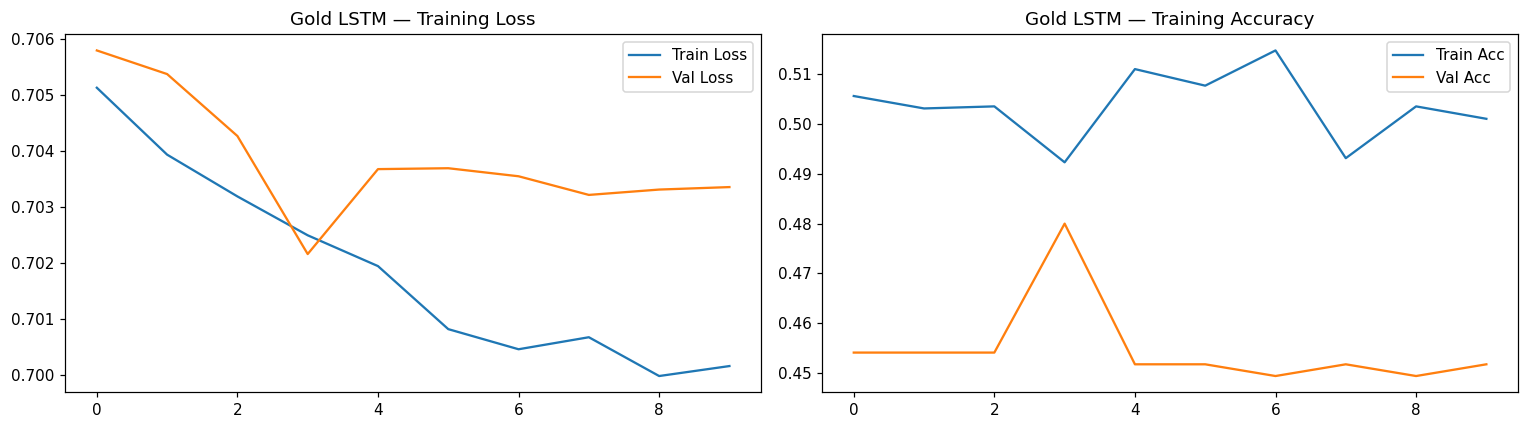

In [25]:
model_au = build_lstm(len(FEATURES))

# 2. Retrain it
history_au = model_au.fit(
    X_tr_au, y_tr_au,
    validation_split=0.15,
    epochs=80, batch_size=32,
    callbacks=callbacks,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_au.history['loss'],     label='Train Loss')
axes[0].plot(history_au.history['val_loss'], label='Val Loss')
axes[0].set_title('Gold LSTM — Training Loss')
axes[0].legend()
axes[1].plot(history_au.history['accuracy'],     label='Train Acc')
axes[1].plot(history_au.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Gold LSTM — Training Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Train — Silver

Epoch 1/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5044 - loss: 0.7053 - val_accuracy: 0.5412 - val_loss: 0.7029 - learning_rate: 5.0000e-04
Epoch 2/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5023 - loss: 0.7034 - val_accuracy: 0.5459 - val_loss: 0.7023 - learning_rate: 5.0000e-04
Epoch 3/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5177 - loss: 0.7022 - val_accuracy: 0.5271 - val_loss: 0.7019 - learning_rate: 5.0000e-04
Epoch 4/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5102 - loss: 0.7011 - val_accuracy: 0.5553 - val_loss: 0.6999 - learning_rate: 5.0000e-04
Epoch 5/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5081 - loss: 0.7007 - val_accuracy: 0.5576 - val_loss: 0.6991 - learning_rate: 5.0000e-04
Epoch 6/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5069 - loss: 0.7005 - val_accuracy: 0.5553 - val_loss: 0.6997 - learning_rate: 2.5000e-04
Epoch 7/80
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5123 - loss

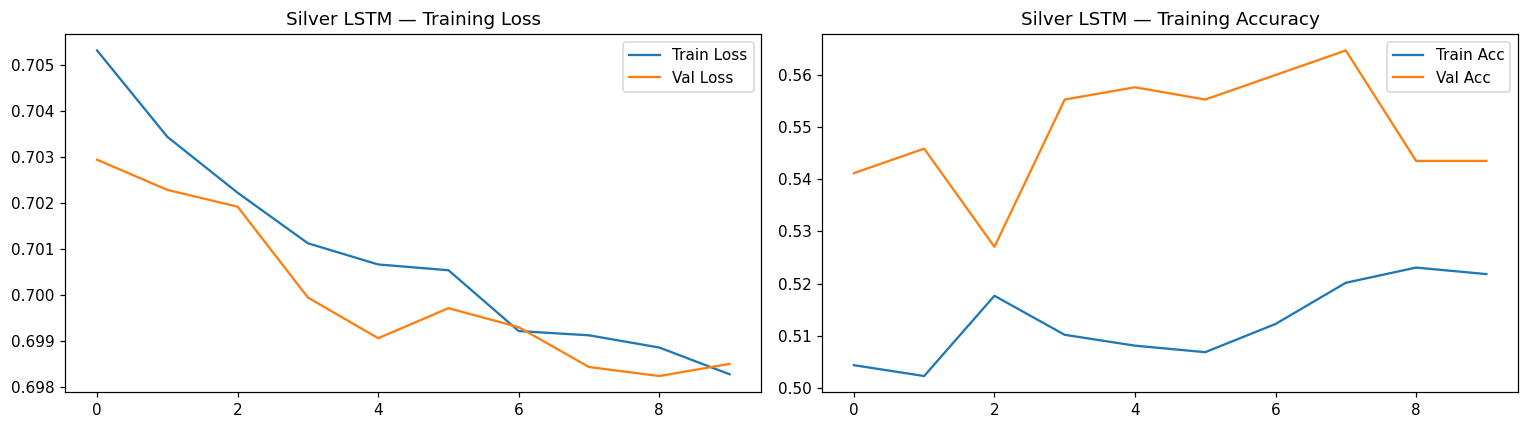

In [15]:
model_ag = build_lstm(len(FEATURES))

history_ag = model_ag.fit(
    X_tr_ag, y_tr_ag,
    validation_split=0.15,
    epochs=80, batch_size=32,
    callbacks=callbacks,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_ag.history['loss'],     label='Train Loss')
axes[0].plot(history_ag.history['val_loss'], label='Val Loss')
axes[0].set_title('Silver LSTM — Training Loss')
axes[0].legend()
axes[1].plot(history_ag.history['accuracy'],     label='Train Acc')
axes[1].plot(history_ag.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Silver LSTM — Training Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Predict & Evaluate

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Gold Dynamic Threshold:   0.5124
Silver Dynamic Threshold: 0.5186

=== LSTM — GOLD (Dynamic Threshold) ===
              precision    recall  f1-score   support

        DOWN       0.48      0.49      0.48       587
          UP       0.51      0.49      0.50       624

    accuracy                           0.49      1211
   macro avg       0.49      0.49      0.49      1211
weighted avg       0.49      0.49      0.49      1211

=== LSTM — SILVER (Dynamic Threshold) ===
              precision    recall  f1-score   support

        DOWN       0.46      0.52      0.49       541
          UP       0.57      0.52      0.54       670

    accuracy                           0.52      1211
   macro avg       0.52      0.52      0.52      1211
weighted avg       0.52      0.52      0.52      1211



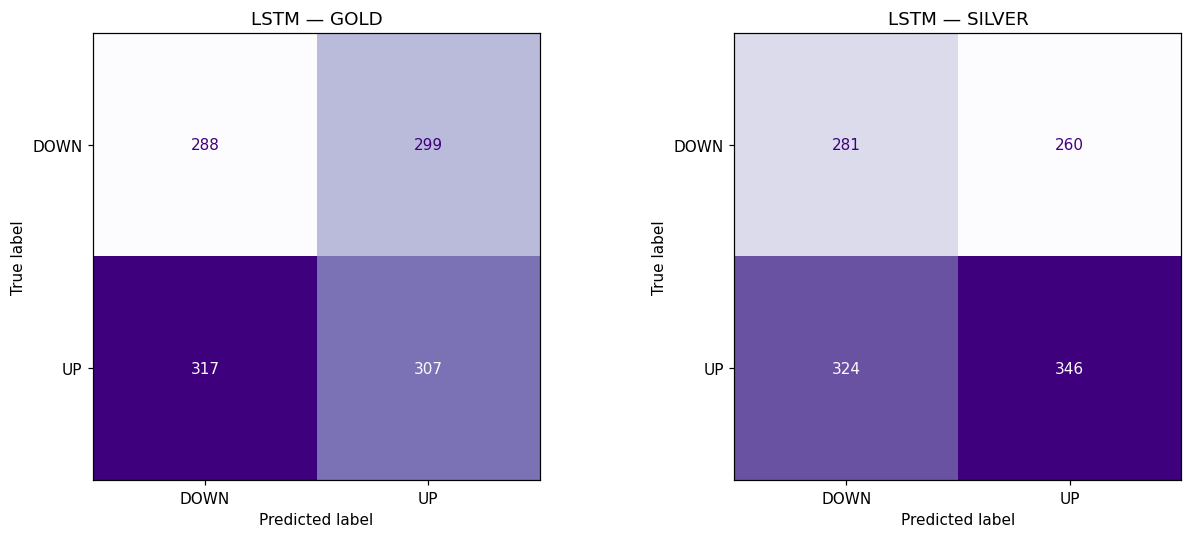

In [26]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get the raw probabilities
prob_lstm_au = model_au.predict(X_te_au).flatten()
prob_lstm_ag = model_ag.predict(X_te_ag).flatten()

# 2. Calculate the dynamic thresholds (the exact median of the predictions)
threshold_au = np.median(prob_lstm_au)
threshold_ag = np.median(prob_lstm_ag)

print(f"Gold Dynamic Threshold:   {threshold_au:.4f}")
print(f"Silver Dynamic Threshold: {threshold_ag:.4f}\n")

# 3. Classify using the NEW dynamic thresholds instead of 0.5
pred_lstm_au = (prob_lstm_au >= threshold_au).astype(int)
pred_lstm_ag = (prob_lstm_ag >= threshold_ag).astype(int)

# 4. Print Reports
print("=== LSTM — GOLD (Dynamic Threshold) ===")
print(classification_report(y_te_au, pred_lstm_au, target_names=['DOWN','UP']))

print("=== LSTM — SILVER (Dynamic Threshold) ===")
print(classification_report(y_te_ag, pred_lstm_ag, target_names=['DOWN','UP']))

# 5. Plot the new Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_te_au, pred_lstm_au),
                       display_labels=['DOWN','UP']).plot(cmap='Purples', ax=axes[0], colorbar=False)
axes[0].set_title('LSTM — GOLD')

ConfusionMatrixDisplay(confusion_matrix(y_te_ag, pred_lstm_ag),
                       display_labels=['DOWN','UP']).plot(cmap='Purples', ax=axes[1], colorbar=False)
axes[1].set_title('LSTM — SILVER')

plt.tight_layout()
plt.show()

## 6. Regime-Wise Evaluation

In [27]:
# Align regime labels with LSTM test dates (offset by seq_len)
split_idx = int(len(df) * 0.70)
test_df = df.iloc[split_idx + SEQ_LEN:]

res_lstm_au = pd.DataFrame({
    'actual'       : y_te_au,
    'pred'         : pred_lstm_au,
    'prob'         : prob_lstm_au,
    'au_returns'   : test_df['au_returns'].values,
    'vol_regime'   : test_df['vol_regime_au'].values,
    'period_regime': test_df['period_regime'].values
}, index=test_df.index)

res_lstm_ag = pd.DataFrame({
    'actual'       : y_te_ag,
    'pred'         : pred_lstm_ag,
    'prob'         : prob_lstm_ag,
    'ag_returns'   : test_df['ag_returns'].values,
    'vol_regime'   : test_df['vol_regime_ag'].values,
    'period_regime': test_df['period_regime'].values
}, index=test_df.index)

regime_eval(res_lstm_au, 'LSTM', 'GOLD',   'vol_regime')
regime_eval(res_lstm_au, 'LSTM', 'GOLD',   'period_regime')
regime_eval(res_lstm_ag, 'LSTM', 'SILVER', 'vol_regime')
regime_eval(res_lstm_ag, 'LSTM', 'SILVER', 'period_regime')


  LSTM | GOLD | by vol_regime
    high_vol     | n= 605 | Acc=0.5124 | F1=0.5110
    low_vol      | n= 606 | Acc=0.4703 | F1=0.4693

  LSTM | GOLD | by period_regime
    covid        | n= 156 | Acc=0.4679 | F1=0.2983
    post_covid   | n=1055 | Acc=0.4948 | F1=0.4921

  LSTM | SILVER | by vol_regime
    high_vol     | n= 666 | Acc=0.5225 | F1=0.5029
    low_vol      | n= 545 | Acc=0.5119 | F1=0.4790

  LSTM | SILVER | by period_regime
    covid        | n= 156 | Acc=0.4679 | F1=0.3379
    post_covid   | n=1055 | Acc=0.5251 | F1=0.5243


[{'regime': 'covid',
  'n': 156,
  'accuracy': 0.46794871794871795,
  'f1': 0.3379335350170525},
 {'regime': 'post_covid',
  'n': 1055,
  'accuracy': 0.5251184834123223,
  'f1': 0.5242870604472422}]

## 7. Backtest

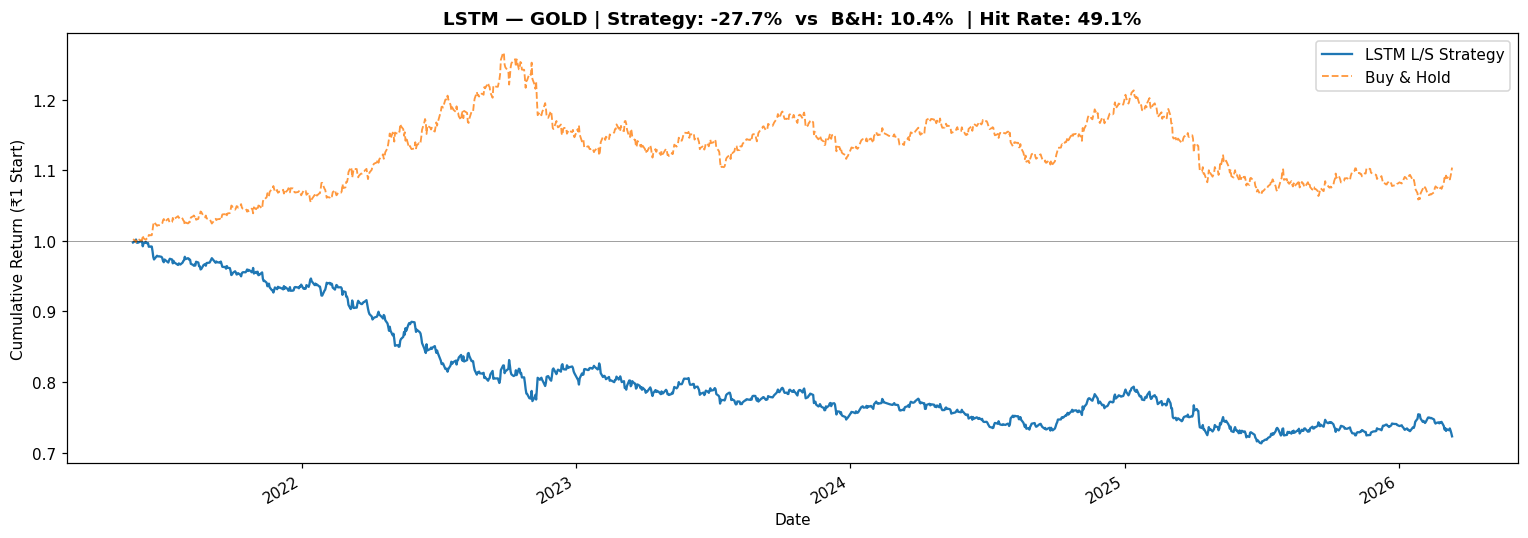

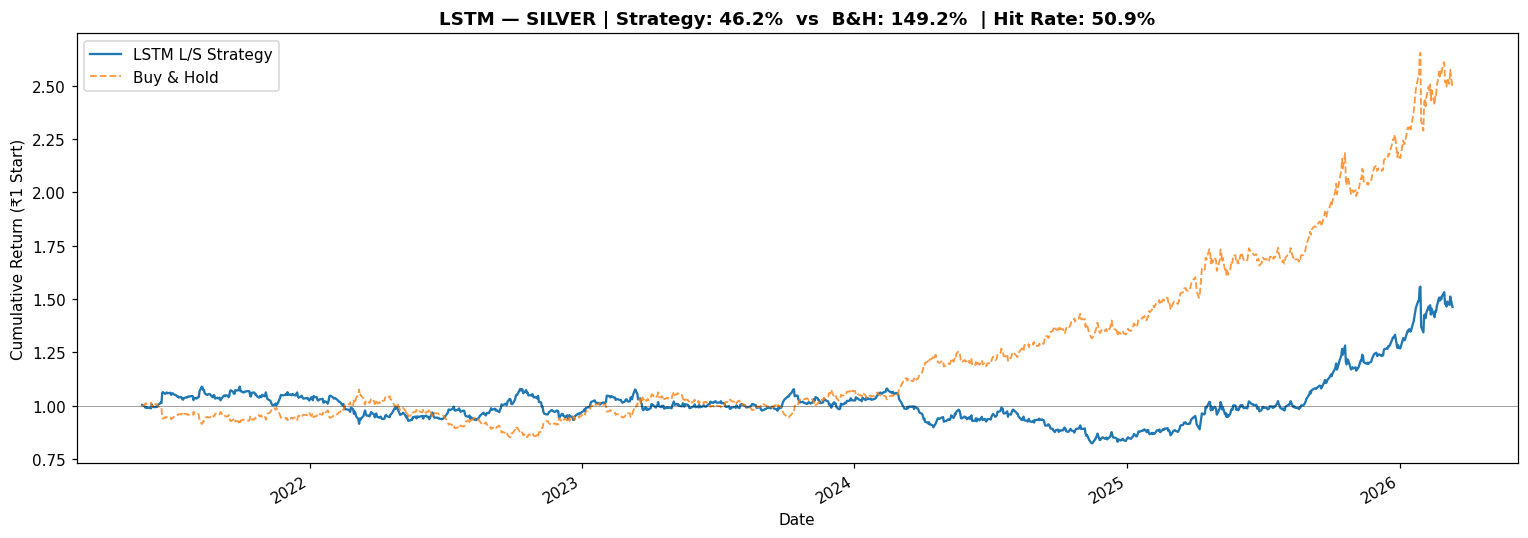

(np.float64(0.46230509309654844),
 np.float64(1.4921846600224655),
 np.float64(0.509496284062758))

In [28]:
run_backtest(res_lstm_au, 'au_returns', 'LSTM', 'GOLD')
run_backtest(res_lstm_ag, 'ag_returns', 'LSTM', 'SILVER')

## 8. Save Predictions

In [29]:
res_lstm_au.to_csv('preds_lstm_au.csv')
res_lstm_ag.to_csv('preds_lstm_ag.csv')
print("Saved: preds_lstm_au.csv, preds_lstm_ag.csv")

Saved: preds_lstm_au.csv, preds_lstm_ag.csv


In [30]:
files.download('preds_lstm_au.csv')
files.download('preds_lstm_ag.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>